### Задача 1. EDA

Изучите таблицу users_info, содержащую информацию о пользователях. Проведите разведочный анализ данных:

**Общая информация о таблице**
+ Сколько в таблице строк и столбцов?
+ Какие типы данных у каждого столбца?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
users_info = pd.read_csv('users_info.csv')
users_info.head()

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
3,1003,Москва,NaN,NaN
4,1004,Екатеринбург,60.0,male


In [3]:
users_info.shape

(1000, 4)

*В таблице users_info 1000 строк и 4 столбца*

In [4]:
users_info.dtypes

id_user      int64
city        object
age        float64
gender      object
dtype: object

*В таблице users_info 2 столбца с числовыми значениями и 2 столбца с нечисловыми значениями*

+ Пропущенные значения + Сколько пропущенных значений в каждом столбце?

In [5]:
users_info.isnull().sum()

id_user     0
city        0
age        88
gender     89
dtype: int64

*Пропущенные значения есть только в двух стоблцах: 88 в столбце Возраст и 89 в столбце Пол*

+ Рассчитайте описательную статистику по колонке возраст (метод describe()). Сильно ли медиана отличается от среднего?

In [6]:
users_info['age'].describe()

count    912.000000
mean      39.419956
std       13.732275
min       18.000000
25%       28.000000
50%       38.000000
75%       51.000000
max       65.000000
Name: age, dtype: float64

In [7]:
print(users_info['age'].median())
print(users_info['age'].mean())

38.0
39.41995614035088


*Медиана отличается от среднего всего на два года. Это несущественная разница*

+ Удалите все строки с пропущенными значениями. Какой процент данных был удалён?

In [9]:
users_info = users_info[~users_info['age'].isnull()]
users_info = users_info[~users_info['gender'].isnull()]
users_info.shape

(865, 4)

*Данные с пропущенными значениями составляеют 8,8% в столбце возрасти 8,9% в столбце пол, что менее 10% в каждом столбце, поэтому их можно безболезненно удалить.*

**Выбросы по возрасту**

Рассчитайте границы для выбросов в колонке age с помощью метода IQR (межквартильного размаха).
Удалите выбросы из таблицы.
Визуализация
Постройте гистограмму (sns.histplot) распределения возрастов пользователей.

In [10]:
Q1 = np.percentile(users_info['age'],25)
Q3 = np.percentile(users_info['age'],75)
IQR = Q3-Q1
lower_border = Q1 - 1.5*IQR
upper_border = Q3+1.5*IQR
print(lower_border, upper_border)

-6.5 85.5


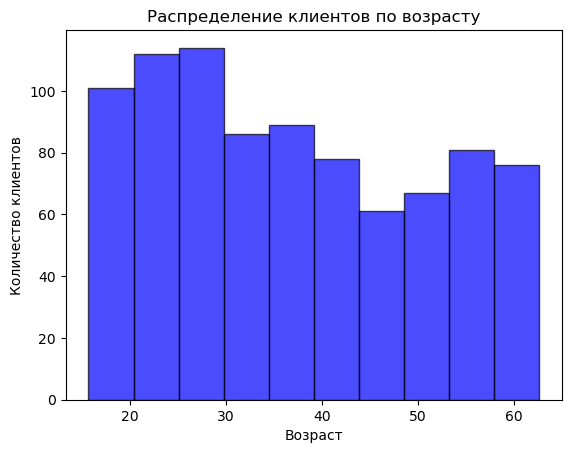

In [93]:
#sns.histplot(users_info['age'])
plt.hist(users_info['age'], bins=10,color='blue',alpha=0.7, edgecolor='black', align = 'left')
plt.xlabel('Возраст')
plt.ylabel('Количество клиентов')
plt.title("Распределение клиентов по возрасту")
plt.show()


In [23]:
users_info_clean = users_info[(users_info['age'] > lower_border) & (users_info['age'] < upper_border)]
users_info_clean.shape

(865, 4)

*Выбросов в данных не обнаружено*

### Задача 2. Доля пользователей-женщин по городам

In [19]:
users_info.head()

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
4,1004,Екатеринбург,60.0,male
5,1005,СПб,35.0,female


+ Рассчитайте количество пользователей по каждому полу и городу с помощью группировки и агрегации.

In [18]:
users_info_cg = users_info.groupby(['city','gender']).agg(cnt_user = ('id_user', 'count')).reset_index()
users_info_cg

,city,gender,cnt_user
0,Екатеринбург,female,55
1,Екатеринбург,male,78
2,Казань,female,53
3,Казань,male,77
4,Москва,female,220
5,Москва,male,105
6,СПб,female,123
7,СПб,male,154


+ Используйте pivot_table, чтобы представить данные: — города в строках, — пол в столбцах.

In [23]:
pivot_user = pd.pivot_table(users_info_cg,\
                           index = 'city',\
                           columns = 'gender' , \
                           values='cnt_user', \
                           aggfunc='sum', \
                           fill_value=0).reset_index()
pivot_user.columns = ['city', 'сnt_female', 'cnt_male']
pivot_user.head()

,city,сnt_female,cnt_male
0,Екатеринбург,55,78
1,Казань,53,77
2,Москва,220,105
3,СПб,123,154


+ Для каждого города рассчитайте долю женщин среди всех пользователей.

In [29]:
pivot_user['cnt_all'] = pivot_user['сnt_female'] + pivot_user['cnt_male']
pivot_user['share_female'] = round(pivot_user['сnt_female']/pivot_user['cnt_all'],2)
pivot_user.head()

,city,сnt_female,cnt_male,cnt_all,share_female
0,Екатеринбург,55,78,133,0.41
1,Казань,53,77,130,0.41
2,Москва,220,105,325,0.68
3,СПб,123,154,277,0.44


+ Постройте столбчатую диаграмму (bar chart), чтобы сравнить долю женщин в разных городах. Какой город отличается от остальных?

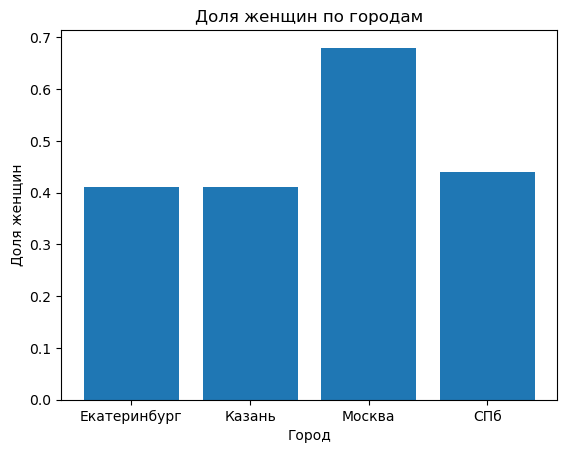

In [32]:
plt.bar(pivot_user['city'], pivot_user['share_female'])
plt.title('Доля женщин по городам')
plt.xlabel('Город')
plt.ylabel('Доля женщин')
plt.show()

*В Москве доля женщин почти на 30% больше по сравнению с другими городами*

### Задача 3. Делим пользователей на бины

+ Загрузите таблицу payments_monthly.csv с платежами, очищенными от выбросов и сгруппированными по месяцам.

In [34]:
pay_mon = pd.read_csv('payments_monthly.csv')
pay_mon.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total
0,1000,2023-03,0,2,0,3600,2,3600
1,1000,2023-04,0,4,0,7200,4,7200
2,1000,2023-05,0,4,0,6400,4,6400
3,1000,2023-06,0,2,0,3600,2,3600
4,1000,2023-07,0,4,0,7200,4,7200


In [37]:
pay_mon.dtypes

id_user       int64
mon          object
cnt_group     int64
cnt_indiv     int64
sum_group     int64
sum_indiv     int64
cnt_total     int64
sum_total     int64
dtype: object

In [38]:
pay_mon.isnull().sum()

id_user      0
mon          0
cnt_group    0
cnt_indiv    0
sum_group    0
sum_indiv    0
cnt_total    0
sum_total    0
dtype: int64

<Axes: ylabel='sum_indiv'>

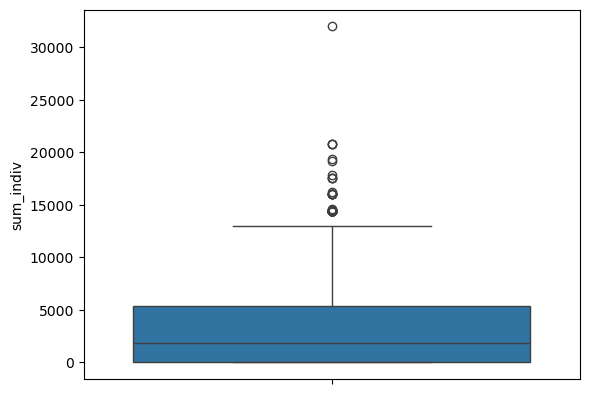

In [39]:
sns.boxplot(pay_mon['sum_indiv'])

In [41]:
Q1 = np.percentile(pay_mon['sum_indiv'],25)
Q3 = np.percentile(pay_mon['sum_indiv'],75)
IQR = Q3-Q1
lower_border = Q1 - 1.5*IQR
upper_border = Q3+1.5*IQR
print(lower_border, upper_border)

-8100.0 13500.0


In [42]:
pay_mon_clean = pay_mon[pay_mon['sum_indiv']<upper_border]

<Axes: ylabel='sum_group'>

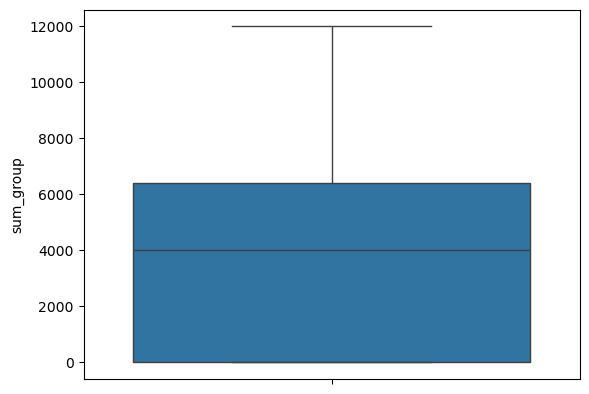

In [43]:
sns.boxplot(pay_mon_clean['sum_group'])

In [44]:
Q1 = np.percentile(pay_mon_clean['sum_group'],25)
Q3 = np.percentile(pay_mon_clean['sum_group'],75)
IQR = Q3-Q1
lower_border = Q1 - 1.5*IQR
upper_border = Q3+1.5*IQR
print(lower_border, upper_border)

-9600.0 16000.0


In [58]:
pay_mon_cc = pay_mon_clean[pay_mon_clean['sum_group']<upper_border]

In [59]:
print(pay_mon.shape)
print(pay_mon_cc.shape)

(5293, 8)
(5206, 8)


+ Рассчитайте среднее количество тренировок в месяц для каждого пользователя.

In [60]:
pay_mon_cc.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total
0,1000,2023-03,0,2,0,3600,2,3600
1,1000,2023-04,0,4,0,7200,4,7200
2,1000,2023-05,0,4,0,6400,4,6400
3,1000,2023-06,0,2,0,3600,2,3600
4,1000,2023-07,0,4,0,7200,4,7200


In [81]:
avg_cnt = pay_mon_cc.groupby('id_user')['cnt_total'].mean().reset_index()
avg_cnt.columns = ['id_user', 'avg_cnt']
avg_cnt.head()

,id_user,avg_cnt
0,1000,3.666667
1,1001,11.727273
2,1002,11.428571
3,1003,5.166667
4,1004,2.000000


+ Разделите пользователей на три группы по уровню активности:
— мало (редко тренируются),
— средне,
— много (тренируются часто).
*Подсказка:* для создания групп используйте функцию cut из библиотеки pandas. Cut используется для деления числового столбца DataFrame на интервалы.

In [82]:
#Смотрим средние значения по количеству тренировок между всеми пользователями для распределения бинов. 
avg_cnt.describe()

,id_user,avg_cnt
count,968.000000,968.000000
mean,1500.520661,6.298991
std,289.208218,3.514964
min,1000.000000,1.000000
25%,1249.750000,3.500000
50%,1501.500000,5.666667
75%,1752.250000,8.804545
max,1998.000000,18.000000


In [85]:
bins = [1, 4, 9, float('inf')] #устанавливаем значения бинов
labels = ['мало', 'средне', 'много'] #устанавливаем названия бинов
#Добавляем столбец с уровнем активности в основную таблицу
pay_mon_cc['activity level'] = pd.cut(avg_cnt['avg_cnt'], bins=bins, labels=labels, right=True)
pay_mon_cc.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,activity level
0,1000,2023-03,0,2,0,3600,2,3600,мало
1,1000,2023-04,0,4,0,7200,4,7200,много
2,1000,2023-05,0,4,0,6400,4,6400,много
3,1000,2023-06,0,2,0,3600,2,3600,средне
4,1000,2023-07,0,4,0,7200,4,7200,мало


+ Посчитайте, сколько пользователей входит в каждую из этих групп.

In [86]:
cnt_bin = pay_mon_cc['activity level'].value_counts()
cnt_bin

activity level
средне    389
мало      308
много     231
Name: count, dtype: int64

In [92]:
#альтернативный вариант подсчета
cnt_bin_alt = pay_mon_cc.groupby('activity level', observed=True).agg(cnt_user = ('id_user', 'count')).reset_index()
cnt_bin_alt

,activity level,cnt_user
0,мало,308
1,средне,389
2,много,231
